# Minimal Maze2D Plot Notebook

This notebook contains the bare minimum code needed to:
- load one trajectory from a local Minari Maze2D dataset
- choose the matching maze definition from code in this notebook
- plot the replay path and stored actions over the maze

In [238]:
import json
import os
import shutil
import site
import subprocess
import sys
import tempfile
import textwrap
import uuid
from contextlib import contextmanager
from pathlib import Path
from types import SimpleNamespace

import h5py
import minari
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display



In [239]:
import shutil
import site

PROJECT_ROOT = Path.cwd()
MINARI_DATASETS_PATH = PROJECT_ROOT / ".minari" / "datasets"
D4RL_PYTHON = Path(r"C:\Users\diank\venv_d4rl\Scripts\python.exe")
MUJOCO_PATH = Path(r"C:\Users\diank\.mujoco\mujoco210")
D4RL_SOURCE = PROJECT_ROOT / "d4rl"
LOCAL_MUJOCO_PY_ROOT = PROJECT_ROOT / ".local_mujoco_py"
DATASET_ID = "analysis/maze2d/medium-raw-v0"
MAZE_SPEC_NAME = "MEDIUM_MAZE_EVAL"  # Numerically validated against maze2d-medium.hdf5
EPISODE_ID = 0
STRIDE = 6


def ensure_local_mujoco_py_copy():
    local_pkg_dir = LOCAL_MUJOCO_PY_ROOT / "mujoco_py"
    if local_pkg_dir.exists():
        return local_pkg_dir

    source_pkg_dir = None
    for package_root in site.getsitepackages():
        candidate = Path(package_root) / "mujoco_py"
        if candidate.exists():
            source_pkg_dir = candidate
            break
    if source_pkg_dir is None:
        raise FileNotFoundError("Could not find mujoco_py in the active Python environment.")

    LOCAL_MUJOCO_PY_ROOT.mkdir(parents=True, exist_ok=True)
    shutil.copytree(source_pkg_dir, local_pkg_dir, dirs_exist_ok=True)
    return local_pkg_dir



In [240]:
MAZE_SPECS = {
    "OPEN": r"#######\#OOOOO#\#OOGOO#\#OOOOO#\#######",
    "U_MAZE": r"#####\#GOO#\###O#\#OOO#\#####",
    "U_MAZE_EVAL": r"#####\#OOG#\#O###\#OOO#\#####",
    "SMALL_MAZE": r"######\#OOOO#\#O##O#\#OOOO#\######",
    "MEDIUM_MAZE": r"########\#OO##OO#\#OO#OOO#\##OOO###\#OO#OOO#\#O#OO#O#\#OOO#OG#\########",
    "MEDIUM_MAZE_EVAL": r"########\#OOOOOG#\#O#O##O#\#OOOO#O#\###OO###\#OOOOOO#\#OO##OO#\########",
    "LARGE_MAZE": r"############\#OOOO#OOOOO#\#O##O#O#O#O#\#OOOOOO#OOO#\#O####O###O#\#OO#O#OOOOO#\##O#O#O#O###\#OO#OOO#OGO#\############",
    "LARGE_MAZE_EVAL": r"############\#OO#OOO#OGO#\##O###O#O#O#\#OO#O#OOOOO#\#O##O#OO##O#\#OOOOOO#OOO#\#O##O#O#O###\#OOOO#OOOOO#\############",
}

QPOS_WORLD_OFFSET = np.array([1.2, 1.2], dtype=np.float32)
QPOS_WALL_CENTER_OFFSET = np.array([-0.2, -0.2], dtype=np.float32)
WALL_HALF_EXTENT = 0.5
PARTICLE_RADIUS = 0.1


def infer_maze_spec_name(dataset_id, available_specs):
    stem = dataset_id.lower().replace("-", "_")
    candidates = []
    for name in available_specs:
        normalized = name.lower().replace("_maze", "")
        candidates.append((normalized, name))
    for normalized, name in sorted(candidates, key=lambda item: len(item[0]), reverse=True):
        if normalized in stem:
            return name
    raise ValueError(f"Could not infer maze spec from dataset id: {dataset_id}")


def parse_maze_rows(maze_str):
    return maze_str.strip().split("\\")


def parse_maze_logic(maze_str):
    maze_rows = parse_maze_rows(maze_str)
    return np.array([[1 if char == "#" else 0 for char in row_text] for row_text in maze_rows], dtype=np.int8)


def qpos_wall_centers_xy(maze_logic):
    return np.argwhere(maze_logic == 1).astype(np.float32) + QPOS_WALL_CENTER_OFFSET


def qpos_free_cell_reference_xy(maze_logic):
    return np.argwhere(maze_logic == 0).astype(np.float32)


maze_spec_name = MAZE_SPEC_NAME or infer_maze_spec_name(DATASET_ID, MAZE_SPECS)
maze_logic = parse_maze_logic(MAZE_SPECS[maze_spec_name])
maze_rows = parse_maze_rows(MAZE_SPECS[maze_spec_name])
wall_cell_centers_xy = np.argwhere(maze_logic == 1).astype(np.float32)
wall_qpos_centers_xy = qpos_wall_centers_xy(maze_logic)
free_cell_reference_xy = qpos_free_cell_reference_xy(maze_logic)
layout = {
    "maze_x_cells": int(maze_logic.shape[0]),
    "maze_y_cells": int(maze_logic.shape[1]),
    "wall_cells_xy": wall_cell_centers_xy.astype(np.int16).tolist(),
    "wall_qpos_centers_xy": wall_qpos_centers_xy.tolist(),
    "free_cells_xy": free_cell_reference_xy.astype(np.int16).tolist(),
}

print("Using maze spec:", maze_spec_name)
print("Maze logical shape (maze_x, maze_y):", tuple(int(v) for v in maze_logic.shape))
print("Exact geometry from live MuJoCo: body/world position = qpos + (1.2, 1.2); wall centers in qpos frame = maze wall indices + (-0.2, -0.2).")


Using maze spec: MEDIUM_MAZE_EVAL
Maze logical shape (maze_x, maze_y): (8, 8)
Exact geometry from live MuJoCo: body/world position = qpos + (1.2, 1.2); wall centers in qpos frame = maze wall indices + (-0.2, -0.2).


In [241]:
os.environ["MINARI_DATASETS_PATH"] = str(MINARI_DATASETS_PATH)
dataset = minari.load_dataset(DATASET_ID)
episode = dataset[EPISODE_ID]

positions = np.asarray(episode.infos["qpos"], dtype=np.float32)
episode_actions = np.asarray(episode.actions, dtype=np.float32)
goal = np.asarray(episode.infos["goal"][0], dtype=np.float32)

print("Loaded dataset:", DATASET_ID)
print("Episode length:", len(episode_actions))

Loaded dataset: analysis/maze2d/medium-raw-v0
Episode length: 124


In [257]:
episode_summary = {
    "observations_shape": episode.observations.shape,
    "actions_shape": episode.actions.shape,
    "goal_shape": episode.infos["goal"].shape,
    "qpos_shape": episode.infos["qpos"].shape,
    "qvel_shape": episode.infos["qvel"].shape,
    "info_keys": list(episode.infos.keys()),
    'rewards': episode.rewards.shape,
}
episode_summary

{'observations_shape': (124, 4),
 'actions_shape': (124, 2),
 'goal_shape': (124, 2),
 'qpos_shape': (124, 2),
 'qvel_shape': (124, 2),
 'info_keys': ['goal', 'qpos', 'qvel', 'raw_index'],
 'rewards': (124,)}

dict_keys(['goal', 'qpos', 'qvel', 'raw_index'])

In [262]:
episode_table = pd.DataFrame(
    {
        "t": np.arange(len(episode.actions), dtype=np.int32),
        "obs_x": episode.observations[:, 0],
        "obs_y": episode.observations[:, 1],
        "obs_vx": episode.observations[:, 2],
        "obs_vy": episode.observations[:, 3],
        "qpos_x": episode.infos["qpos"][:, 0],
        "qpos_y": episode.infos["qpos"][:, 1],
        "goal_x": episode.infos["goal"][:, 0],
        "goal_y": episode.infos["goal"][:, 1],
        "action_x": episode.actions[:, 0],
        "action_y": episode.actions[:, 1],
        "rewards": episode.rewards,
        "terminated": episode.terminations,
        "truncated": episode.truncations,
    }
)
episode_table.head(10)

,t,obs_x,obs_y,obs_vx,obs_vy,qpos_x,qpos_y,goal_x,goal_y,action_x,action_y,rewards,terminated,truncated
0,0,4.944978,4.084466,0.008865,0.045366,4.944978,4.084466,5.995181,0.912286,0.125213,-0.681920,0.112269,False,False
1,1,4.945365,4.083295,0.038665,-0.117150,4.945365,4.083295,5.995181,0.912286,-1.000000,-1.000000,0.112175,False,False
2,2,4.943369,4.079744,-0.199591,-0.355035,4.943369,4.079744,5.995181,0.912286,-0.244802,-0.592145,0.111719,False,False
3,3,4.940795,4.074792,-0.257418,-0.495217,4.940795,4.074792,5.995181,0.912286,-1.000000,-1.000000,0.111097,False,False
4,4,4.935845,4.067470,-0.494969,-0.732202,4.935845,4.067470,5.995181,0.912286,-0.401482,-0.988491,0.110124,False,False
5,5,4.929951,4.057811,-0.589409,-0.965881,4.929951,4.057811,5.995181,0.912286,-0.059175,-1.000000,0.108886,False,False
6,6,4.923930,4.045794,-0.602098,-1.201744,4.923930,4.045794,5.995181,0.912286,0.397371,-0.789803,0.107433,False,False
7,7,4.918870,4.031924,-0.506025,-1.386984,4.918870,4.031924,5.995181,0.912286,0.078696,-1.000000,0.105877,False,False
8,8,4.914009,4.015706,-0.486077,-1.621845,4.914009,4.015706,5.995181,0.912286,-0.315761,-0.831028,0.104138,False,False
9,9,4.908408,3.997547,-0.560122,-1.815903,4.908408,3.997547,5.995181,0.912286,0.818448,-1.000000,0.102217,False,False


In [244]:
ensure_local_mujoco_py_copy()
os.environ["MUJOCO_PY_MUJOCO_PATH"] = str(MUJOCO_PATH)
os.environ["D4RL_SUPPRESS_IMPORT_ERROR"] = "1"
os.environ["PATH"] = str(MUJOCO_PATH / "bin") + ";" + os.environ.get("PATH", "")
try:
    os.add_dll_directory(str(MUJOCO_PATH / "bin"))
except (AttributeError, FileNotFoundError):
    pass
sys.path.insert(0, str(LOCAL_MUJOCO_PY_ROOT))
sys.path.insert(0, str(D4RL_SOURCE))

from d4rl.pointmaze import dynamic_mjc
from d4rl.pointmaze.maze_model import MazeEnv

@contextmanager
def windows_safe_asfile(self):
    fd, xml_path = tempfile.mkstemp(suffix=".xml")
    os.close(fd)
    try:
        with open(xml_path, "w", encoding="utf-8") as f:
            self.root.write(f)
        yield SimpleNamespace(name=xml_path)
    finally:
        try:
            os.remove(xml_path)
        except OSError:
            pass

dynamic_mjc.MJCModel.asfile = windows_safe_asfile


def replay_actions_with_mujoco(initial_qpos, initial_qvel, actions, maze_spec):
    env = MazeEnv(maze_spec=maze_spec, reward_type="dense", reset_target=False)
    try:
        env.set_state(np.asarray(initial_qpos, dtype=np.float32), np.asarray(initial_qvel, dtype=np.float32))
        replayed_positions = [env.sim.data.qpos.astype(float).copy()]
        replayed_velocities = [env.sim.data.qvel.astype(float).copy()]
        for action in np.asarray(actions, dtype=np.float32):
            env.step(action)
            replayed_positions.append(env.sim.data.qpos.astype(float).copy())
            replayed_velocities.append(env.sim.data.qvel.astype(float).copy())
    finally:
        env.close()
    return (
        np.asarray(replayed_positions, dtype=np.float32),
        np.asarray(replayed_velocities, dtype=np.float32),
    )

exact_positions, exact_velocities = replay_actions_with_mujoco(
    initial_qpos=episode.infos["qpos"][0],
    initial_qvel=episode.infos["qvel"][0],
    actions=episode.actions[:3],
    maze_spec=MAZE_SPECS[maze_spec_name],
)
rolled_positions = exact_positions
rolled_velocities = exact_velocities

rolled_table = pd.DataFrame(
    {
        "t": np.arange(len(rolled_positions), dtype=np.int32),
        "rolled_x": rolled_positions[:, 0],
        "rolled_y": rolled_positions[:, 1],
        "rolled_vx": rolled_velocities[:, 0],
        "rolled_vy": rolled_velocities[:, 1],
        "action_x": np.append(episode.actions[:3, 0], np.nan),
        "action_y": np.append(episode.actions[:3, 1], np.nan),
    }
)
rolled_table


,t,rolled_x,rolled_y,rolled_vx,rolled_vy,action_x,action_y
0,0,4.944978,4.084466,0.008865,0.045366,0.125213,-0.681920
1,1,4.945365,4.083294,0.038665,-0.117150,-1.000000,-1.000000
2,2,4.943369,4.079744,-0.199591,-0.355035,-0.244802,-0.592145
3,3,4.940795,4.074792,-0.257418,-0.495217,NaN,NaN


In [245]:
import sys
print(sys.executable)


c:\Users\diank\venv_d4rl\Scripts\python.exe


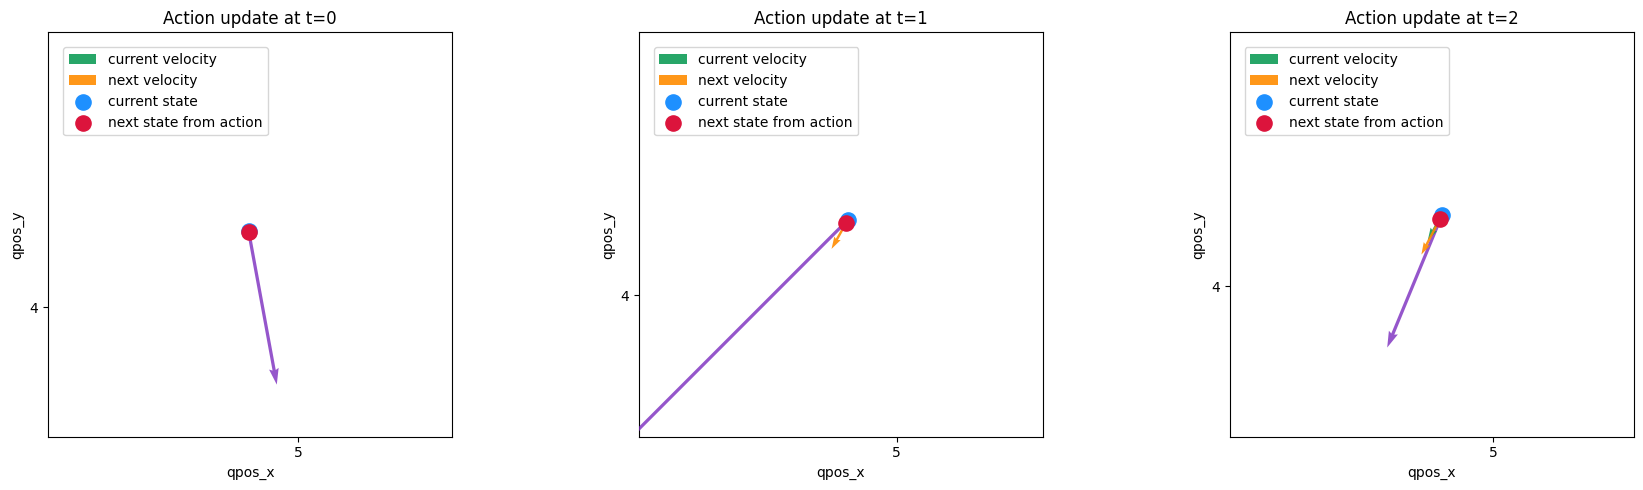

In [246]:
def qpos_display_grid(maze_logic):
    return maze_logic.T


def draw_qpos_maze(ax, maze_logic):
    ax.imshow(
        qpos_display_grid(maze_logic),
        origin="lower",
        cmap="gray_r",
        vmin=0,
        vmax=1,
        extent=(-0.7, maze_logic.shape[0] - 0.3, -0.7, maze_logic.shape[1] - 0.3),
    )
    ax.set_xlim(-0.7, maze_logic.shape[0] - 0.3)
    ax.set_ylim(-0.7, maze_logic.shape[1] - 0.3)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(maze_logic.shape[0]))
    ax.set_yticks(np.arange(maze_logic.shape[1]))
    ax.set_xticks(np.arange(-0.5, maze_logic.shape[0], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, maze_logic.shape[1], 1), minor=True)
    ax.grid(which="minor", color="lightgray", linewidth=0.8)
    ax.set_xlabel("qpos_x")
    ax.set_ylabel("qpos_y")


def zoom_to_local_transition(ax, current_position, next_position, current_velocity, next_velocity, padding=0.18, min_window=0.45, velocity_scale=0.08):
    velocity_points = np.vstack([
        current_position,
        next_position,
        current_position + velocity_scale * current_velocity,
        next_position + velocity_scale * next_velocity,
    ])
    x_min = np.min(velocity_points[:, 0]) - padding
    x_max = np.max(velocity_points[:, 0]) + padding
    y_min = np.min(velocity_points[:, 1]) - padding
    y_max = np.max(velocity_points[:, 1]) + padding

    width = max(x_max - x_min, min_window)
    height = max(y_max - y_min, min_window)
    window_size = max(width, height)
    center_x = 0.5 * (x_min + x_max)
    center_y = 0.5 * (y_min + y_max)

    ax.set_xlim(center_x - 0.5 * window_size, center_x + 0.5 * window_size)
    ax.set_ylim(center_y - 0.5 * window_size, center_y + 0.5 * window_size)


TIMESTEPS_TO_SHOW = [0, 1, 2]
VELOCITY_SCALE = 0.08

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, t in zip(axes, TIMESTEPS_TO_SHOW):
    current_position = rolled_positions[t]
    next_position = rolled_positions[t + 1]
    current_velocity = rolled_velocities[t]
    next_velocity = rolled_velocities[t + 1]
    draw_qpos_maze(ax, maze_logic)
    ax.quiver(
        current_position[0],
        current_position[1],
        episode.actions[t, 0],
        episode.actions[t, 1],
        angles="xy",
        scale_units="xy",
        scale=4,
        color="#7b2cbf",
        width=0.008,
        alpha=0.8,
        zorder=3,
    )
    ax.quiver(
        current_position[0],
        current_position[1],
        current_velocity[0],
        current_velocity[1],
        angles="xy",
        scale_units="xy",
        scale=1 / VELOCITY_SCALE,
        color="#0f9d58",
        width=0.006,
        alpha=0.9,
        label="current velocity",
        zorder=4,
    )
    ax.quiver(
        next_position[0],
        next_position[1],
        next_velocity[0],
        next_velocity[1],
        angles="xy",
        scale_units="xy",
        scale=1 / VELOCITY_SCALE,
        color="#ff8c00",
        width=0.006,
        alpha=0.9,
        label="next velocity",
        zorder=4,
    )
    ax.scatter(current_position[0], current_position[1], c="dodgerblue", s=120, label="current state", zorder=4)
    ax.scatter(next_position[0], next_position[1], c="crimson", s=120, label="next state from action", zorder=5)
    zoom_to_local_transition(ax, current_position, next_position, current_velocity, next_velocity, velocity_scale=VELOCITY_SCALE)
    ax.set_title(f"Action update at t={t}")
    ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98))

plt.tight_layout()
plt.show()


In [247]:
draw_maze = draw_qpos_maze



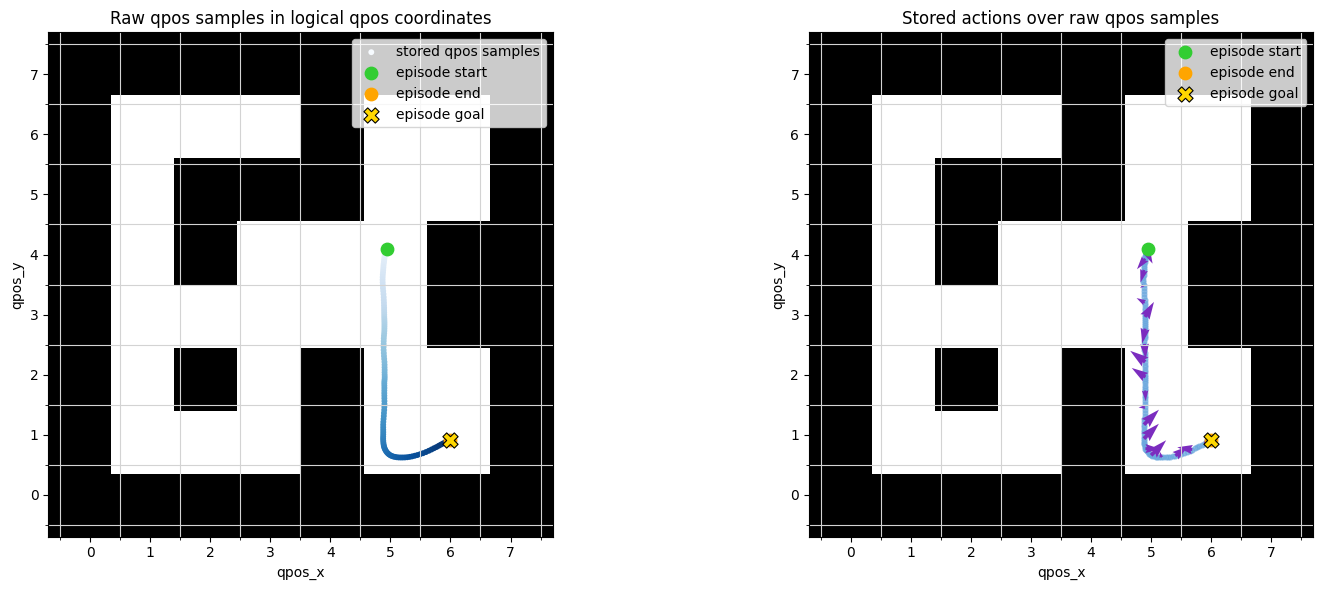

In [248]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax in axes:
    draw_qpos_maze(ax, maze_logic)

axes[0].scatter(positions[:, 0], positions[:, 1], c=np.linspace(0.15, 0.95, len(positions)), cmap="Blues", s=18, edgecolors="none", label="stored qpos samples")
axes[0].scatter(positions[0, 0], positions[0, 1], c="limegreen", s=80, label="episode start")
axes[0].scatter(positions[-1, 0], positions[-1, 1], c="orange", s=80, label="episode end")
axes[0].scatter(goal[0], goal[1], c="gold", s=120, marker="X", edgecolors="black", linewidths=0.8, label="episode goal")
axes[0].set_title("Raw qpos samples in logical qpos coordinates")
axes[0].legend(loc="best")

axes[1].scatter(positions[:, 0], positions[:, 1], c="#6aa7de", s=12, alpha=0.6)
axes[1].quiver(
    positions[::STRIDE, 0],
    positions[::STRIDE, 1],
    episode_actions[::STRIDE, 0],
    episode_actions[::STRIDE, 1],
    angles="xy",
    scale_units="xy",
    scale=4,
    color="#7b2cbf",
)
axes[1].scatter(positions[0, 0], positions[0, 1], c="limegreen", s=80, label="episode start")
axes[1].scatter(positions[-1, 0], positions[-1, 1], c="orange", s=80, label="episode end")
axes[1].scatter(goal[0], goal[1], c="gold", s=120, marker="X", edgecolors="black", linewidths=0.8, label="episode goal")
axes[1].set_title("Stored actions over raw qpos samples")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()


In [ ]:
DISCRETE_GRID_SHAPE = tuple(int(v) for v in maze_logic.shape)
DISCRETE_GRID_X, DISCRETE_GRID_Y = DISCRETE_GRID_SHAPE

def wall_rectangles_from_layout(layout):
    rectangles = []
    width = layout["width"]
    for row, col in layout["wall_cells"]:
        x = width - 1 - col
        y = row
        rectangles.append((x - 0.5, y - 0.5, 1.0, 1.0))
    return rectangles

def make_discrete_maze(maze_logic, grid_shape=None):
    if grid_shape is None:
        grid_shape = tuple(int(v) for v in maze_logic.shape)
    if tuple(grid_shape) != tuple(int(v) for v in maze_logic.shape):
        raise ValueError("This notebook keeps the discrete maze in the same logical (maze_x, maze_y) coordinates as qpos.")
    return np.asarray(maze_logic, dtype=np.int32).copy()


def discretize_points(points_xy, free_cell_reference_xy):
    points_xy = np.asarray(points_xy, dtype=np.float32)
    distances = ((points_xy[:, None, :] - free_cell_reference_xy[None, :, :]) ** 2).sum(axis=2)
    nearest_indices = distances.argmin(axis=1)
    return free_cell_reference_xy[nearest_indices].astype(np.int16)


discrete_maze = make_discrete_maze(maze_logic, grid_shape=DISCRETE_GRID_SHAPE)
maze_space_positions = positions.copy()
discrete_path = discretize_points(positions, free_cell_reference_xy)
discrete_goal = discretize_points(goal[None, :], free_cell_reference_xy)[0]
discrete_unique_path = np.unique(discrete_path, axis=0)

discrete_episode_table = pd.DataFrame(
    {
        "t": np.arange(len(discrete_path), dtype=np.int32),
        "maze_x_cell": discrete_path[:, 0],
        "maze_y_cell": discrete_path[:, 1],
        "qpos_x": maze_space_positions[:, 0],
        "qpos_y": maze_space_positions[:, 1],
        "hits_wall": [bool(discrete_maze[cell_x, cell_y]) for cell_x, cell_y in discrete_path],
    }
)

print("Discrete grid shape (maze_x, maze_y):", DISCRETE_GRID_SHAPE)
print("Discrete goal cell (maze_x, maze_y):", tuple(int(v) for v in discrete_goal))
print("Unique path cells visited:", len(discrete_unique_path))
print("Any wall cells hit after nearest-free projection:", bool(discrete_episode_table["hits_wall"].any()))
discrete_episode_table.head(12)


Discrete grid shape (maze_x, maze_y): (8, 8)
Discrete goal cell (maze_x, maze_y): (6, 1)
Unique path cells visited: 5
Any wall cells hit after nearest-free projection: False


,t,maze_x_cell,maze_y_cell,qpos_x,qpos_y,hits_wall
0,0,5,4,4.944978,4.084466,False
1,1,5,4,4.945365,4.083295,False
2,2,5,4,4.943369,4.079744,False
3,3,5,4,4.940795,4.074792,False
4,4,5,4,4.935845,4.067470,False
5,5,5,4,4.929951,4.057811,False
6,6,5,4,4.923930,4.045794,False
7,7,5,4,4.918870,4.031924,False
8,8,5,4,4.914009,4.015706,False
9,9,5,4,4.908408,3.997547,False


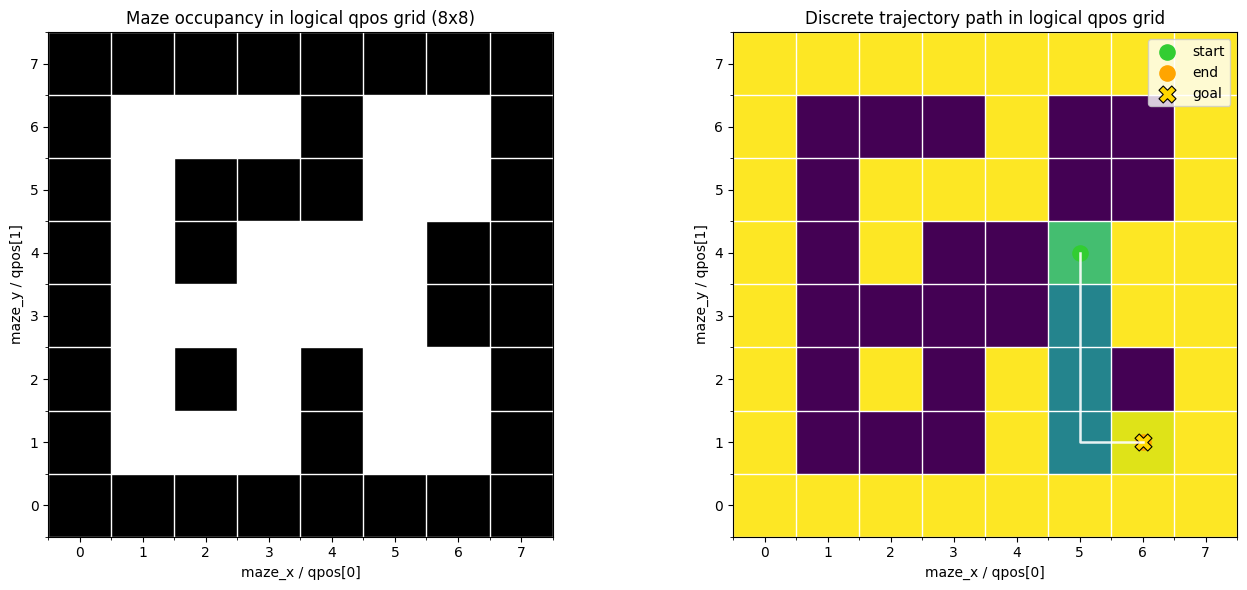

In [250]:
discrete_path_overlay = np.zeros((discrete_maze.shape[1], discrete_maze.shape[0]), dtype=np.float32)
discrete_path_overlay[discrete_maze.T == 1] = 1.0
for maze_x, maze_y in discrete_unique_path:
    if discrete_maze[maze_x, maze_y] == 0:
        discrete_path_overlay[maze_y, maze_x] = 0.45

start_x, start_y = discrete_path[0]
end_x, end_y = discrete_path[-1]
goal_x, goal_y = discrete_goal
discrete_path_overlay[start_y, start_x] = 0.7
discrete_path_overlay[end_y, end_x] = 0.85
discrete_path_overlay[goal_y, goal_x] = 0.95

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(
    discrete_maze.T,
    origin="lower",
    cmap="Greys",
    vmin=0,
    vmax=1,
    extent=(-0.5, DISCRETE_GRID_X - 0.5, -0.5, DISCRETE_GRID_Y - 0.5),
)
axes[0].set_title(f"Maze occupancy in logical qpos grid ({DISCRETE_GRID_X}x{DISCRETE_GRID_Y})")

axes[1].imshow(
    discrete_path_overlay,
    origin="lower",
    cmap="viridis",
    vmin=0,
    vmax=1,
    extent=(-0.5, DISCRETE_GRID_X - 0.5, -0.5, DISCRETE_GRID_Y - 0.5),
)
axes[1].plot(discrete_path[:, 0], discrete_path[:, 1], color="white", linewidth=1.8, alpha=0.9)
axes[1].scatter(start_x, start_y, c="limegreen", s=120, label="start")
axes[1].scatter(end_x, end_y, c="orange", s=120, label="end")
axes[1].scatter(goal_x, goal_y, c="gold", s=150, marker="X", edgecolors="black", linewidths=0.8, label="goal")
axes[1].set_title("Discrete trajectory path in logical qpos grid")

for ax in axes:
    ax.set_xticks(np.arange(DISCRETE_GRID_X))
    ax.set_yticks(np.arange(DISCRETE_GRID_Y))
    ax.set_xlabel("maze_x / qpos[0]")
    ax.set_ylabel("maze_y / qpos[1]")
    ax.set_xticks(np.arange(-0.5, DISCRETE_GRID_X, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, DISCRETE_GRID_Y, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)

axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()


## Discretized trajectory-path dataset

This section exports the full dataset of **discrete path sequences** for the current Maze2D dataset.
It keeps only the visited cell path for each episode and does **not** store the original action vectors.


In [ ]:
from collections import deque

DISCRETE_PATH_DATASET_PATH = PROJECT_ROOT / "maze2d_discrete_trajectory_paths_8x8.npz"


def collapse_repeated_cells(path):
    path = np.asarray(path, dtype=np.int16)
    if len(path) == 0:
        return path.reshape(0, 2)
    keep = np.ones(len(path), dtype=bool)
    keep[1:] = np.any(path[1:] != path[:-1], axis=1)
    return path[keep]


def shortest_grid_path(maze, start_cell, end_cell):
    start_cell = tuple(np.asarray(start_cell, dtype=np.int16).tolist())
    end_cell = tuple(np.asarray(end_cell, dtype=np.int16).tolist())

    if start_cell == end_cell:
        return np.asarray([start_cell], dtype=np.int16)

    grid_x, grid_y = maze.shape
    queue = deque([start_cell])
    previous = {start_cell: None}

    while queue:
        cell_x, cell_y = queue.popleft()
        if (cell_x, cell_y) == end_cell:
            break

        for next_x, next_y in ((cell_x - 1, cell_y), (cell_x + 1, cell_y), (cell_x, cell_y - 1), (cell_x, cell_y + 1)):
            if not (0 <= next_x < grid_x and 0 <= next_y < grid_y):
                continue
            if maze[next_x, next_y] != 0:
                continue
            if (next_x, next_y) in previous:
                continue
            previous[(next_x, next_y)] = (cell_x, cell_y)
            queue.append((next_x, next_y))

    if end_cell not in previous:
        raise RuntimeError(f"No free-cell path found between {start_cell} and {end_cell}.")

    path = []
    current = end_cell
    while current is not None:
        path.append(current)
        current = previous[current]
    path.reverse()
    return np.asarray(path, dtype=np.int16)


def connect_discrete_path(path, maze):
    collapsed = collapse_repeated_cells(path)
    if len(collapsed) == 0:
        return collapsed

    connected_segments = [collapsed[:1]]
    for next_cell in collapsed[1:]:
        segment = shortest_grid_path(maze, connected_segments[-1][-1], next_cell)
        connected_segments.append(segment[1:])

    connected_path = np.concatenate(connected_segments, axis=0)
    return collapse_repeated_cells(connected_path)


def build_discrete_path_dataset(minari_dataset, free_cell_reference_xy, grid_shape, maze, maze_name):
    episode_ids = np.arange(len(minari_dataset), dtype=np.int32)
    paths = np.empty(len(minari_dataset), dtype=object)
    raw_lengths = np.zeros(len(minari_dataset), dtype=np.int32)
    path_lengths = np.zeros(len(minari_dataset), dtype=np.int32)
    start_cells = np.zeros((len(minari_dataset), 2), dtype=np.int16)
    end_cells = np.zeros((len(minari_dataset), 2), dtype=np.int16)
    goal_cells = np.zeros((len(minari_dataset), 2), dtype=np.int16)

    for episode_id in episode_ids:
        episode = minari_dataset[int(episode_id)]
        raw_path = discretize_points(episode.infos["qpos"], free_cell_reference_xy)
        connected_path = connect_discrete_path(raw_path, maze)
        discrete_goal_cell = discretize_points(episode.infos["goal"][:1], free_cell_reference_xy)[0]

        paths[int(episode_id)] = connected_path.astype(np.int16)
        raw_lengths[int(episode_id)] = len(raw_path)
        path_lengths[int(episode_id)] = len(connected_path)
        start_cells[int(episode_id)] = connected_path[0]
        end_cells[int(episode_id)] = connected_path[-1]
        goal_cells[int(episode_id)] = discrete_goal_cell.astype(np.int16)

    return {
        "maze_name": np.array([maze_name]),
        "coordinate_convention": np.array(["logical_qpos_xy"]),
        "grid_shape": np.asarray(grid_shape, dtype=np.int32),
        "maze": np.asarray(maze, dtype=np.int8),
        "episode_ids": episode_ids,
        "raw_lengths": raw_lengths,
        "path_lengths": path_lengths,
        "start_cells": start_cells,
        "end_cells": end_cells,
        "goal_cells": goal_cells,
        "paths": paths,
    }


discrete_path_dataset = build_discrete_path_dataset(
    minari_dataset=dataset,
    free_cell_reference_xy=free_cell_reference_xy,
    grid_shape=DISCRETE_GRID_SHAPE,
    maze=discrete_maze,
    maze_name=maze_spec_name,
)

np.savez(DISCRETE_PATH_DATASET_PATH, **discrete_path_dataset)

wall_hit_count = sum(
    any(discrete_maze[tuple(cell)] == 1 for cell in np.asarray(path_cells, dtype=np.int16))
    for path_cells in discrete_path_dataset["paths"]
)

discrete_path_summary = pd.DataFrame(
    [
        (
            str(DISCRETE_PATH_DATASET_PATH),
            discrete_path_dataset["coordinate_convention"][0],
            len(discrete_path_dataset["episode_ids"]),
            tuple(int(v) for v in discrete_path_dataset["grid_shape"]),
            int(discrete_path_dataset["path_lengths"].min()),
            float(np.median(discrete_path_dataset["path_lengths"])),
            int(discrete_path_dataset["path_lengths"].max()),
            int(wall_hit_count),
        )
    ],
    columns=[
        "path",
        "coordinate_convention",
        "episodes",
        "grid_shape",
        "min_path_length",
        "median_path_length",
        "max_path_length",
        "episodes_with_wall_hits",
    ],
)

discrete_path_preview = pd.DataFrame(
    {
        "episode_id": discrete_path_dataset["episode_ids"][:8],
        "path_length": discrete_path_dataset["path_lengths"][:8],
        "start_cell_xy": [path.tolist() for path in discrete_path_dataset["start_cells"][:8]],
        "end_cell_xy": [path.tolist() for path in discrete_path_dataset["end_cells"][:8]],
        "goal_cell_xy": [path.tolist() for path in discrete_path_dataset["goal_cells"][:8]],
        "first_path_cells_xy": [discrete_path_dataset["paths"][i][:8].tolist() for i in range(min(8, len(discrete_path_dataset["paths"])))],
    }
)

print("Saved discrete trajectory-path dataset to:", DISCRETE_PATH_DATASET_PATH)
display(discrete_path_summary)
display(discrete_path_preview)




Saved discrete trajectory-path dataset to: c:\4th year\project\maze2d_discrete_trajectory_paths_8x8.npz


,path,coordinate_convention,episodes,grid_shape,min_path_length,median_path_length,max_path_length,episodes_with_wall_hits
0,c:\4th year\project\maze2d_discrete_trajectory...,logical_qpos_xy,12560,"(8, 8)",1,6.0,14,0


,episode_id,path_length,start_cell_xy,end_cell_xy,goal_cell_xy,first_path_cells_xy
0,0,5,"[5, 4]","[6, 1]","[6, 1]","[[5, 4], [5, 3], [5, 2], [5, 1], [6, 1]]"
1,1,10,"[6, 1]","[1, 1]","[1, 1]","[[6, 1], [6, 2], [5, 2], [5, 3], [4, 3], [3, 3..."
2,2,2,"[1, 1]","[1, 2]","[1, 2]","[[1, 1], [1, 2]]"
3,3,6,"[1, 2]","[2, 6]","[2, 6]","[[1, 2], [1, 3], [1, 4], [1, 5], [1, 6], [2, 6]]"
4,4,11,"[2, 6]","[5, 5]","[5, 5]","[[2, 6], [1, 6], [1, 5], [1, 4], [1, 3], [2, 3..."
5,5,8,"[5, 5]","[2, 1]","[2, 1]","[[5, 5], [5, 4], [5, 3], [4, 3], [3, 3], [3, 2..."
6,6,8,"[2, 1]","[2, 6]","[2, 6]","[[2, 1], [1, 1], [1, 2], [1, 3], [1, 4], [1, 5..."
7,7,10,"[2, 6]","[5, 4]","[5, 4]","[[2, 6], [1, 6], [1, 5], [1, 4], [1, 3], [2, 3..."


## Continuous trajectory validation

These plots use the exact live-MuJoCo geometry in the `qpos` frame.
- particle/body world position is `qpos + (1.2, 1.2)`
- wall centers in the `qpos` frame are at `maze wall index + (-0.2, -0.2)`
- only raw point samples are used here; connected lines are not used as geometric evidence


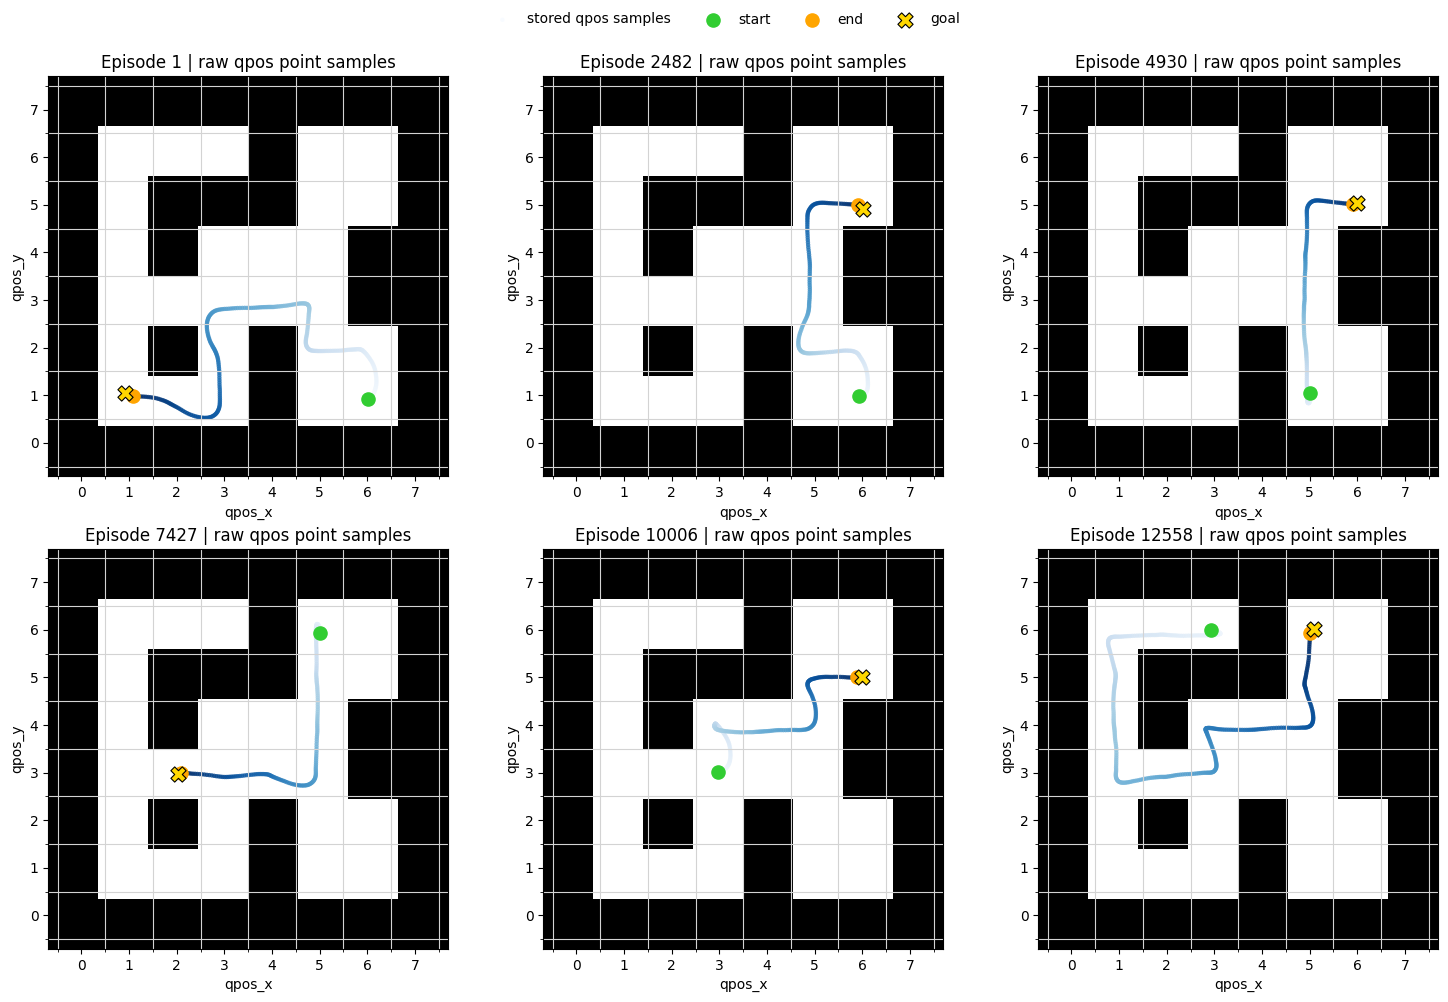

In [252]:
num_examples = min(6, len(discrete_path_dataset["paths"]))
candidate_indices = np.flatnonzero(discrete_path_dataset["path_lengths"] >= np.median(discrete_path_dataset["path_lengths"]))
if len(candidate_indices) >= num_examples:
    CONTINUOUS_SAMPLE_EPISODES = candidate_indices[np.linspace(0, len(candidate_indices) - 1, num_examples, dtype=int)]
else:
    CONTINUOUS_SAMPLE_EPISODES = np.linspace(0, len(discrete_path_dataset["paths"]) - 1, num_examples, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = np.asarray(axes).ravel()

for ax, sample_idx in zip(axes, CONTINUOUS_SAMPLE_EPISODES):
    validation_episode = dataset[int(sample_idx)]
    continuous_positions = np.asarray(validation_episode.infos["qpos"], dtype=np.float32)
    continuous_goal = np.asarray(validation_episode.infos["goal"][0], dtype=np.float32)
    point_colors = np.linspace(0.15, 0.95, len(continuous_positions))

    draw_qpos_maze(ax, discrete_maze)
    ax.scatter(
        continuous_positions[:, 0],
        continuous_positions[:, 1],
        c=point_colors,
        cmap="Blues",
        s=10,
        alpha=0.85,
        edgecolors="none",
        label="stored qpos samples",
    )
    ax.scatter(continuous_positions[0, 0], continuous_positions[0, 1], c="limegreen", s=90, label="start")
    ax.scatter(continuous_positions[-1, 0], continuous_positions[-1, 1], c="orange", s=90, label="end")
    ax.scatter(continuous_goal[0], continuous_goal[1], c="gold", s=120, marker="X", edgecolors="black", linewidths=0.8, label="goal")
    ax.set_title(f"Episode {int(discrete_path_dataset['episode_ids'][int(sample_idx)])} | raw qpos point samples")

for ax in axes[len(CONTINUOUS_SAMPLE_EPISODES):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


## Step-by-step episode validation

This section compares candidate maze layouts numerically and validates the selected layout in the same exact `qpos` frame used for plotting.
It reports both point-center wall hits and the stricter particle-radius overlap count.


Validation dataset file: c:\4th year\project\maze2d-medium.hdf5
Validation episode: 1
Goal qpos (qpos_x, qpos_y): (0.9083130955696106, 1.0521589517593384)
All projected discrete cells are free: True
Maze-spec comparison using exact qpos-frame wall geometry:


,maze_spec,raw_qpos_center_hits,raw_qpos_center_hit_fraction,particle_radius_overlap_hits,particle_radius_overlap_fraction
1,MEDIUM_MAZE_EVAL,0,0.000000,1707,0.000853
0,MEDIUM_MAZE,789633,0.394817,871826,0.435913


,t,qpos_x,qpos_y,nearest_free_maze_x,nearest_free_maze_y,qpos_center_inside_wall,particle_radius_overlaps_wall,projected_cell_hits_wall
0,0,6.025140,0.932031,6,1,False,False,False
1,1,6.049048,0.947025,6,1,False,False,False
2,2,6.070518,0.962558,6,1,False,False,False
3,3,6.089678,0.978436,6,1,False,False,False
4,4,6.106574,0.996657,6,1,False,False,False
5,5,6.121047,1.017216,6,1,False,False,False
6,6,6.134747,1.040109,6,1,False,False,False
7,7,6.146748,1.064766,6,1,False,False,False
8,8,6.157385,1.091746,6,1,False,False,False
9,9,6.166495,1.121043,6,1,False,False,False


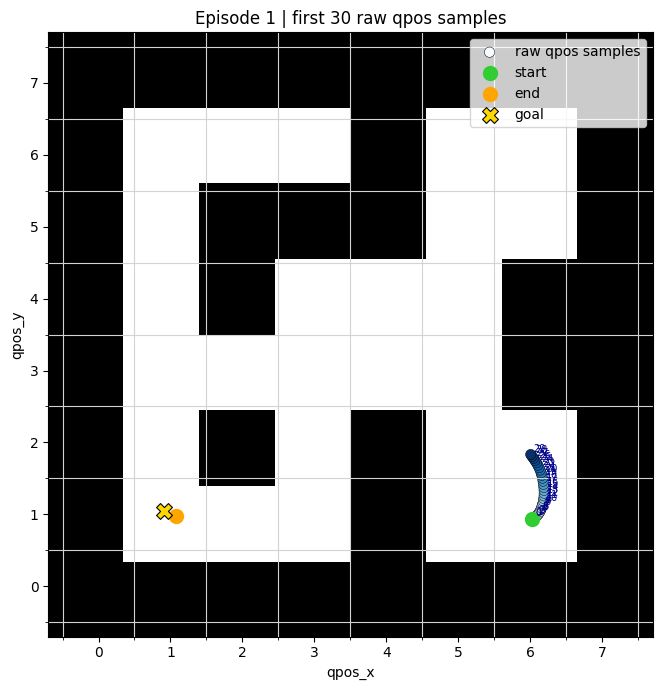

,episode_id,selected_maze_spec,raw_qpos_center_hits_full_dataset,particle_radius_overlap_hits_full_dataset,discrete_path_preview_xy
0,1,MEDIUM_MAZE_EVAL,0,1707,"[[6, 1], [6, 2], [5, 2], [5, 3], [4, 3], [3, 3..."


In [253]:
DATASET_HDF5_PATH = PROJECT_ROOT / "maze2d-medium.hdf5"
VALIDATION_EPISODE_ID = int(CONTINUOUS_SAMPLE_EPISODES[0])
VALIDATION_MAX_POINTS = 30


def qpos_points_inside_wall_rectangles(points_xy, wall_qpos_centers_xy, half_extent=0.5, chunk_size=200000):
    points_xy = np.asarray(points_xy, dtype=np.float32)
    wall_qpos_centers_xy = np.asarray(wall_qpos_centers_xy, dtype=np.float32)
    hit_mask = np.zeros(len(points_xy), dtype=bool)
    for start in range(0, len(points_xy), chunk_size):
        stop = min(start + chunk_size, len(points_xy))
        pts = points_xy[start:stop]
        hit_mask[start:stop] = (
            (np.abs(pts[:, None, 0] - wall_qpos_centers_xy[None, :, 0]) <= half_extent)
            & (np.abs(pts[:, None, 1] - wall_qpos_centers_xy[None, :, 1]) <= half_extent)
        ).any(axis=1)
    return hit_mask


def qpos_wall_overlap_with_particle_radius(points_xy, wall_qpos_centers_xy, half_extent=0.5 + PARTICLE_RADIUS, chunk_size=200000):
    return qpos_points_inside_wall_rectangles(points_xy, wall_qpos_centers_xy, half_extent=half_extent, chunk_size=chunk_size)


with h5py.File(DATASET_HDF5_PATH, "r") as f:
    all_raw_qpos = np.asarray(f["infos/qpos"], dtype=np.float32)

candidate_spec_names = ["MEDIUM_MAZE", "MEDIUM_MAZE_EVAL"] if "medium" in DATASET_ID.lower() else [maze_spec_name]
layout_comparison_rows = []
for candidate_name in candidate_spec_names:
    candidate_logic = parse_maze_logic(MAZE_SPECS[candidate_name])
    candidate_wall_qpos_centers = qpos_wall_centers_xy(candidate_logic)
    center_hit_mask = qpos_points_inside_wall_rectangles(all_raw_qpos, candidate_wall_qpos_centers, half_extent=WALL_HALF_EXTENT)
    overlap_hit_mask = qpos_wall_overlap_with_particle_radius(all_raw_qpos, candidate_wall_qpos_centers)
    layout_comparison_rows.append(
        {
            "maze_spec": candidate_name,
            "raw_qpos_center_hits": int(center_hit_mask.sum()),
            "raw_qpos_center_hit_fraction": float(center_hit_mask.mean()),
            "particle_radius_overlap_hits": int(overlap_hit_mask.sum()),
            "particle_radius_overlap_fraction": float(overlap_hit_mask.mean()),
        }
    )

layout_comparison_table = pd.DataFrame(layout_comparison_rows).sort_values("raw_qpos_center_hit_fraction", kind="stable")

validation_episode = dataset[VALIDATION_EPISODE_ID]
validation_positions = np.asarray(validation_episode.infos["qpos"], dtype=np.float32)
validation_goal = np.asarray(validation_episode.infos["goal"][0], dtype=np.float32)
validation_discrete_path = np.asarray(discrete_path_dataset["paths"][VALIDATION_EPISODE_ID], dtype=np.int16)
validation_projection = discretize_points(validation_positions, free_cell_reference_xy)
validation_projection_hits_wall = np.array([bool(discrete_maze[cell_x, cell_y]) for cell_x, cell_y in validation_projection], dtype=bool)
validation_center_hits = qpos_points_inside_wall_rectangles(validation_positions, wall_qpos_centers_xy, half_extent=WALL_HALF_EXTENT)
validation_radius_overlaps = qpos_wall_overlap_with_particle_radius(validation_positions, wall_qpos_centers_xy)

validation_table = pd.DataFrame(
    {
        "t": np.arange(len(validation_positions), dtype=np.int32),
        "qpos_x": validation_positions[:, 0],
        "qpos_y": validation_positions[:, 1],
        "nearest_free_maze_x": validation_projection[:, 0],
        "nearest_free_maze_y": validation_projection[:, 1],
        "qpos_center_inside_wall": validation_center_hits,
        "particle_radius_overlaps_wall": validation_radius_overlaps,
        "projected_cell_hits_wall": validation_projection_hits_wall,
    }
)

print("Validation dataset file:", DATASET_HDF5_PATH)
print("Validation episode:", VALIDATION_EPISODE_ID)
print("Goal qpos (qpos_x, qpos_y):", tuple(float(v) for v in validation_goal))
print("All projected discrete cells are free:", bool((~validation_projection_hits_wall).all()))
print("Maze-spec comparison using exact qpos-frame wall geometry:")
display(layout_comparison_table)
display(validation_table.head(VALIDATION_MAX_POINTS))

fig, ax = plt.subplots(figsize=(7, 7))
draw_qpos_maze(ax, discrete_maze)
plot_count = min(VALIDATION_MAX_POINTS, len(validation_positions))
point_colors = np.linspace(0.15, 0.95, plot_count)
ax.scatter(
    validation_positions[:plot_count, 0],
    validation_positions[:plot_count, 1],
    c=point_colors,
    cmap="Blues",
    s=55,
    edgecolors="black",
    linewidths=0.35,
    label="raw qpos samples",
)
for step_idx in range(plot_count):
    ax.text(
        validation_positions[step_idx, 0] + 0.04,
        validation_positions[step_idx, 1] + 0.04,
        str(step_idx),
        fontsize=7,
        color="darkblue",
    )
ax.scatter(validation_positions[0, 0], validation_positions[0, 1], c="limegreen", s=100, label="start")
ax.scatter(validation_positions[-1, 0], validation_positions[-1, 1], c="orange", s=100, label="end")
ax.scatter(validation_goal[0], validation_goal[1], c="gold", s=130, marker="X", edgecolors="black", linewidths=0.8, label="goal")
ax.set_title(f"Episode {VALIDATION_EPISODE_ID} | first {plot_count} raw qpos samples")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "episode_id": [VALIDATION_EPISODE_ID],
        "selected_maze_spec": [maze_spec_name],
        "raw_qpos_center_hits_full_dataset": [int(layout_comparison_table.iloc[0]["raw_qpos_center_hits"])],
        "particle_radius_overlap_hits_full_dataset": [int(layout_comparison_table.iloc[0]["particle_radius_overlap_hits"])],
        "discrete_path_preview_xy": [validation_discrete_path[: min(20, len(validation_discrete_path))].tolist()],
    }
)


## Original Maze2D mazes

These are the original built-in Maze2D maze layouts, plotted directly from the hard-coded maze specs in this notebook.


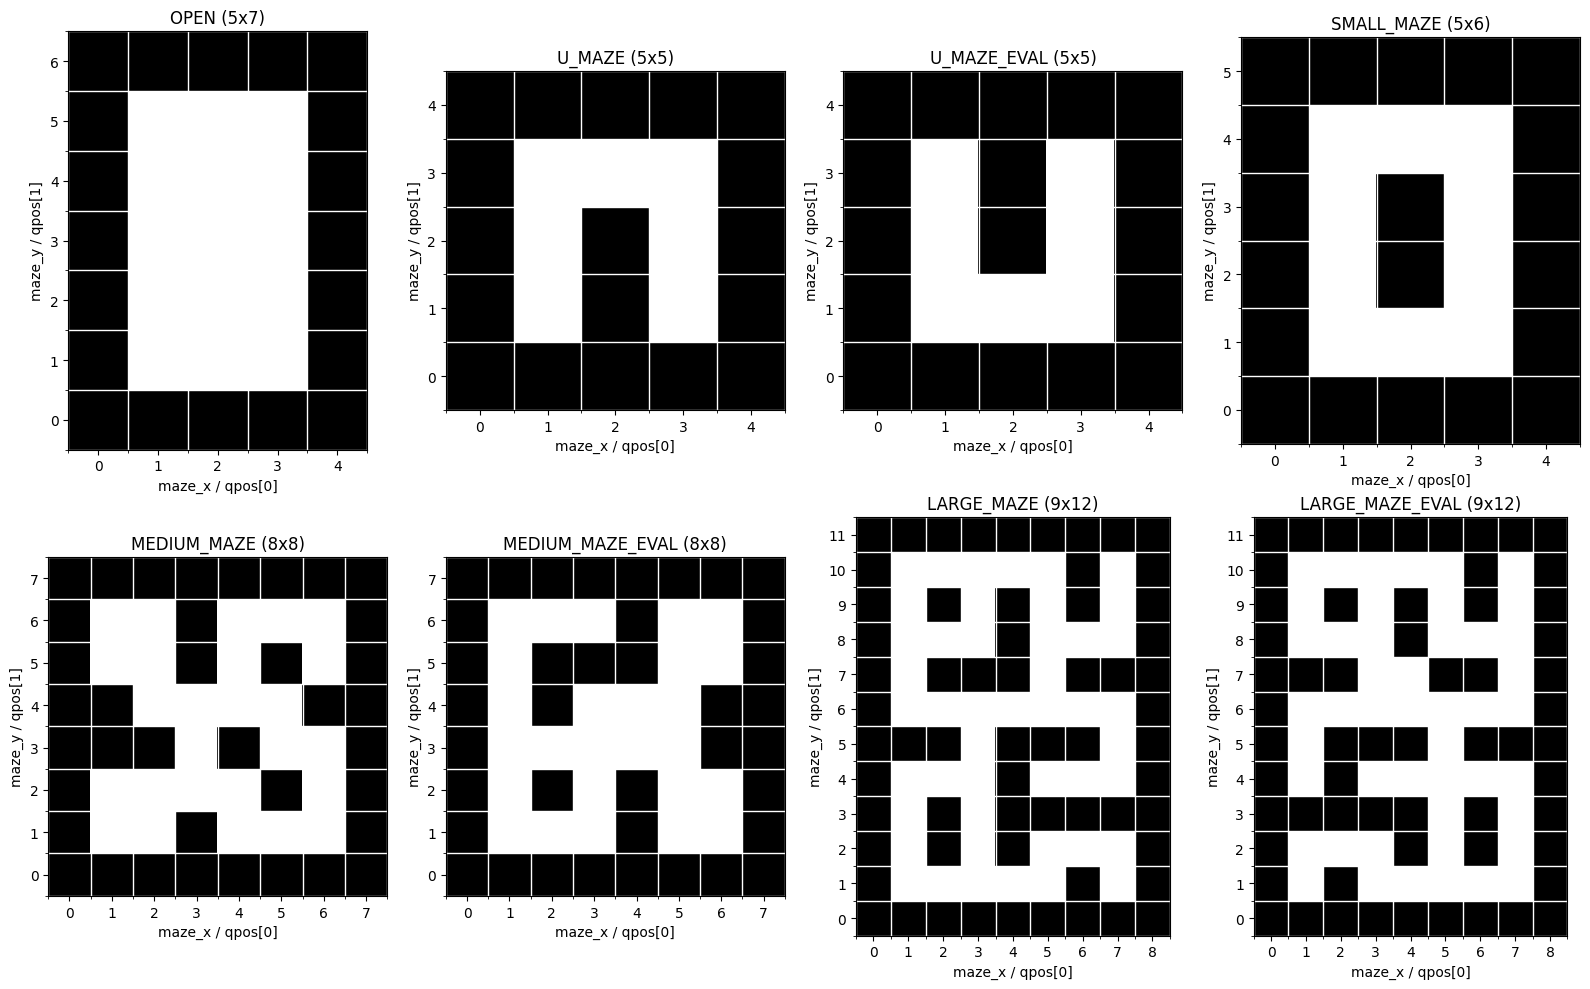

In [254]:
original_maze_names = list(MAZE_SPECS.keys())
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = np.asarray(axes).ravel()

for ax, original_name in zip(axes, original_maze_names):
    original_logic = parse_maze_logic(MAZE_SPECS[original_name])
    ax.imshow(
        qpos_display_grid(original_logic),
        origin="lower",
        cmap="Greys",
        vmin=0,
        vmax=1,
        extent=(-0.5, original_logic.shape[0] - 0.5, -0.5, original_logic.shape[1] - 0.5),
    )
    ax.set_title(f"{original_name} ({original_logic.shape[0]}x{original_logic.shape[1]})")
    ax.set_xticks(np.arange(original_logic.shape[0]))
    ax.set_yticks(np.arange(original_logic.shape[1]))
    ax.set_xticks(np.arange(-0.5, original_logic.shape[0], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, original_logic.shape[1], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.set_xlabel("maze_x / qpos[0]")
    ax.set_ylabel("maze_y / qpos[1]")

for ax in axes[len(original_maze_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

